In [29]:
from pathlib import Path
import os 

cwd = Path.cwd()

if cwd.parts[-1] != 'NonLinear_FEMSM':
    os.chdir("..")
    cwd = Path.cwd()

In [35]:
df_results.columns

Index(['data_id', 'N', 'T', 'rho', 'a', 'p', 'tau_f_true', 'tau_c_true',
       'tau_f_fe', 'tau_c_fe', 'tau_f_fe_impute', 'tau_c_fe_impute',
       'tau_f_no_fe', 'tau_c_no_fe', 'tau_f_true_se', 'tau_c_true_se',
       'tau_f_fe_se', 'tau_c_fe_se', 'tau_f_fe_impute_se',
       'tau_c_fe_impute_se', 'tau_f_no_fe_se', 'tau_c_no_fe_se', 'seed',
       'tau_c', 'tau_f'],
      dtype='object')

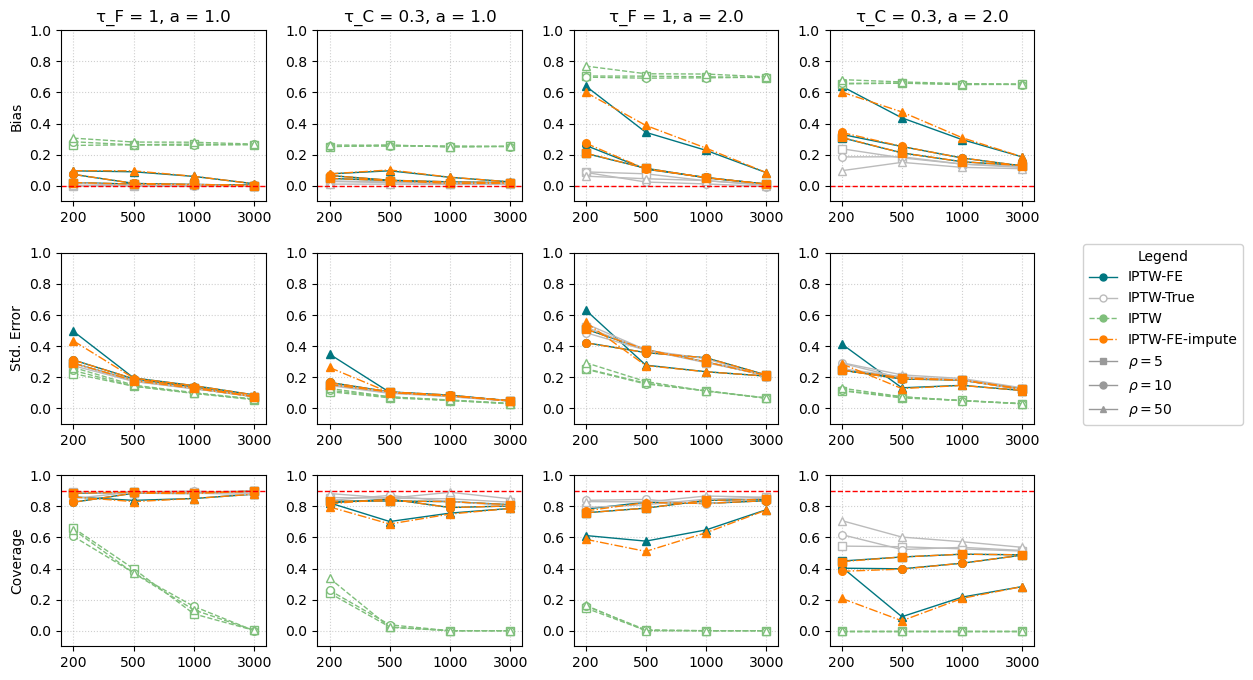

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm

df_results = pd.read_csv(cwd/"results"/"msm"/"fe_msm_results_monotone_included.csv")
df_results["tau_c"] = 0.3
df_results["tau_f"] = 1.0

z_90 = norm.ppf(0.95)

# -----------------------------------
# 1) Prepare long data with tau_hats
# -----------------------------------

# NEW: keep both a = 1 and a = 2 (only filter on p)
dfp = df_results.loc[(df_results.p == 2)].copy()

methods = ["IPTW-FE", "IPTW-True", "IPTW", "IPTW-FE-impute"]

tau_f_cols = {
    "IPTW-FE":   "tau_f_fe",
    "IPTW-True": "tau_f_true",
    "IPTW":      "tau_f_no_fe",
    "IPTW-FE-impute":      "tau_f_fe_impute",
}
tau_c_cols = {
    "IPTW-FE":   "tau_c_fe",
    "IPTW-True": "tau_c_true",
    "IPTW":      "tau_c_no_fe",
    "IPTW-FE-impute":      "tau_c_fe_impute",
}

rows = []
for _, r in dfp.iterrows():
    for m in methods:
        # τ_F
        rows.append({
            "a":       r["a"],          # NEW: keep a
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_F = 1",
            "method":  m,
            "tau_hat": r[tau_f_cols[m]],
            "tau_true": r["tau_f"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_f_fe_se",
                         "IPTW-True":"tau_f_true_se",
                         "IPTW":"tau_f_no_fe_se",
                         "IPTW-FE-impute": "tau_f_fe_impute_se",
                         }[m]]
        })
        # τ_C
        rows.append({
            "a":       r["a"],          
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_C = 0.3",
            "method":  m,
            "tau_hat": r[tau_c_cols[m]],
            "tau_true": r["tau_c"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_c_fe_se",
                         "IPTW-True":"tau_c_true_se",
                         "IPTW":"tau_c_no_fe_se",
                         "IPTW-FE-impute": "tau_c_fe_impute_se", }[m]]
        })

long_df = pd.DataFrame(rows).sort_values(["a", "param", "method", "rho", "N"])

# diffs per simulation
long_df["diff"] = long_df["tau_hat"] - long_df["tau_true"]
long_df["abs_diff"] = long_df["diff"].abs()

# 90% Wald CI using HC2 SEs
long_df["ci_low"]  = long_df["tau_hat"] - z_90 * long_df["se_hat"]
long_df["ci_high"] = long_df["tau_hat"] + z_90 * long_df["se_hat"]
long_df["covered"] = (
    (long_df["tau_true"] >= long_df["ci_low"]) &
    (long_df["tau_true"] <= long_df["ci_high"])
).astype(float)

# -----------------------------------
# 2) Aggregate over seeds
# -----------------------------------
agg_df = (
    long_df
    .groupby(["a", "N", "rho", "param", "method"], as_index=False)  # NEW: include a
    .agg(
        bias_abs=("abs_diff", "mean"),   # mean |bias|
        std_tau=("tau_hat", "std"),      # MC std of estimator
        bias = ("diff", "mean"),         # mean bias
        coverage = ("covered", "mean")
    )
)

# -----------------------------------
# 3) Plot: 3 rows (bias, std, coverage) × 4 cols (a=1,2 × τ_F, τ_C)
# -----------------------------------
method_ls    = {"IPTW-FE": "-", "IPTW-True": "-", "IPTW": "--", "IPTW-FE-impute": "-."}
method_color = {"IPTW-FE": "#007680", "IPTW-True": "#BBBBBB", "IPTW": "#7FBF7B", "IPTW-FE-impute": "#FF7F00"}
rho_markers  = {5: "s", 10: "o", 50: "^"}

# NEW: 3 rows x 4 columns
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=False, sharey=False)

params = ["τ_F = 1", "τ_C = 0.3"]
a_vals = sorted(agg_df["a"].unique())   # expects [1, 2]

unique_N = sorted(agg_df["N"].unique())
xpos = {n: i for i, n in enumerate(unique_N)}

rowspecs = [
    (0, "bias",      "Bias"),
    (1, "std_tau",   "Std. Error"),
    (2, "coverage",  "Coverage"),
]

for row_idx, metric_col, ylabel in rowspecs:
    for a_idx, a_val in enumerate(a_vals):
        for p_idx, param in enumerate(params):
            col_idx = 2 * a_idx + p_idx   # 0,1 -> a=1 ; 2,3 -> a=2
            ax = axes[row_idx, col_idx]

            # subset for this (a, param)
            sub = agg_df[(agg_df["a"] == a_val) & (agg_df["param"] == param)]

            for method in methods:
                for rho, g in sub[sub["method"] == method].groupby("rho"):
                    x = g["N"].map(xpos)
                    ax.plot(
                        x,
                        g[metric_col],
                        linestyle=method_ls[method],
                        color=method_color[method],
                        marker=rho_markers.get(rho, "o"),
                        markerfacecolor=(
                            "white" if method in ("IPTW-True", "IPTW") else method_color[method]
                        ),
                        lw=1,
                        markersize=5.5,
                    )

            ax.set_xticks(range(len(unique_N)))
            ax.set_xticklabels(unique_N)
            ax.set_xlim(-0.2, len(unique_N) - 0.8)
            # Only left-most column gets a y-label
            if col_idx == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_ylabel("")
           

            if row_idx == 0:
                # NEW: title shows param and a
                ax.set_title(f"{param}, a = {a_val}")

            ax.grid(True, linestyle=":", alpha=0.6)

            # Horizontal reference lines
            if metric_col == "bias":
                # zero bias
                ax.axhline(0.0, color="red", linestyle="--", linewidth=1)
            elif metric_col == "coverage":
                # nominal 90% coverage
                ax.axhline(0.9, color="red", linestyle="--", linewidth=1)


            # Optional: nicer y-limits for coverage vs others
            
            ax.set_ylim(-0.1, 1)

# -----------------------------------
# 4) One combined legend outside
# -----------------------------------
method_handles = [
    Line2D([0],[0], color=method_color["IPTW-FE"],   linestyle="-",  marker="o", lw=1, markersize=5, label="IPTW-FE"),
    Line2D([0],[0], color=method_color["IPTW-True"], linestyle="-",  marker="o", lw=1, markersize=5,
           markerfacecolor="white", label="IPTW-True"),
    Line2D([0],[0], color=method_color["IPTW"],      linestyle="--", marker="o", lw=1, markersize=5, label="IPTW"),
    Line2D([0],[0], color=method_color["IPTW-FE-impute"],      linestyle="-.", marker="o", lw=1, markersize=5, label="IPTW-FE-impute"),
]
shape_handles = [
    Line2D([0],[0], color="0.6", linestyle="-", marker="s", lw=1, markersize=5, label=r"$\rho=5$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="o", lw=1, markersize=5, label=r"$\rho=10$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="^", lw=1, markersize=5, label=r"$\rho=50$"),
]
all_handles = method_handles + shape_handles
all_labels  = [h.get_label() for h in all_handles]

fig.legend(
    all_handles, all_labels,
    loc="center left", bbox_to_anchor=(0.85, 0.5),
    frameon=True, fancybox=True, framealpha=0.9,
    title="Legend", ncol=1,
)

fig.subplots_adjust(right=0.82, hspace=0.3, wspace=0.25)
plt.show()


In [24]:
df = pd.read_csv("results/msm/fe_msm_results.csv")
sub = df[(df["a"]==2) & (df["p"]==2)]
print(sub.groupby("N")["tau_c_true"].mean())


N
200     0.466691
500     0.441551
1000    0.432479
3000    0.419631
Name: tau_c_true, dtype: float64


In [26]:
import pandas as pd

df = pd.read_csv("results/msm/fe_msm_results.csv")

sub = df[(df["a"] == 2) & (df["p"] == 2)]  # or p==4 if you ran that
print(sub.groupby("N")[["tau_c_true", "tau_c_true_se"]].mean())


      tau_c_true  tau_c_true_se
N                              
200     0.466691       0.234115
500     0.441551       0.164908
1000    0.432479       0.135648
3000    0.419631       0.099619
